# UN Geographic Region Maps

Choropleth maps showing how countries are tagged by UN region, subregion, and continent.

In [1]:
using VegaLite, VegaDatasets, DataFrames, CSV

# Load geographic lookup
geo = CSV.read("data/ggis_geographic_lookup.csv", DataFrame)

# VegaDatasets world-110m uses numeric country IDs
# We need to join on ident_ccode (ISO 3166-1 numeric)
println("Loaded $(nrow(geo)) country mappings")
first(geo, 5)

Loaded 209 country mappings


Row,ident_cname,ident_ccode,ident_ccodealp,ht_region,un_region_name,un_region_code,un_subregion_name,un_subregion_code,continent,continent_code
,String,Int64,String7,Int64,String15,Int64,String31,Int64,String15,String3
1,Afghanistan,4,AFG,8,Asia,142,Southern Asia,34,Asia,AS
2,Albania,8,ALB,1,Europe,150,Southern Europe,39,Europe,EU
3,Algeria,12,DZA,3,Africa,2,Northern Africa,15,Africa,AF
4,Andorra,20,AND,5,Europe,150,Southern Europe,39,Europe,EU
5,Angola,24,AGO,4,Africa,2,Sub-Saharan Africa,202,Africa,AF


## 1. UN Regions (6 macro regions)

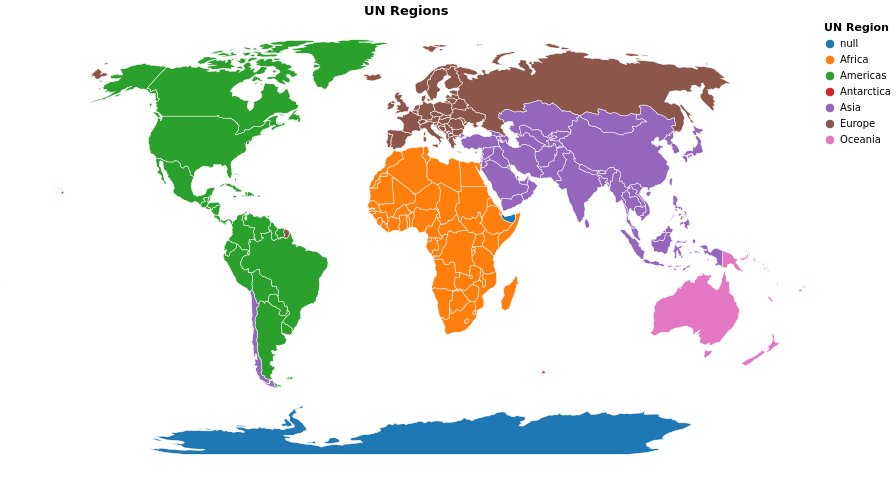

In [2]:
world = dataset("world-110m")

@vlplot(
    width=800, height=450,
    title="UN Regions",
    projection={type=:naturalEarth1},
) +
@vlplot(
    mark={type=:geoshape, stroke=:white, strokeWidth=0.5},
    data={values=world, format={type=:topojson, feature=:countries}},
    transform=[{
        lookup=:id,
        from={
            data=geo,
            key=:ident_ccode,
            fields=["un_region_name", "un_region_code"]
        }
    }],
    color={
        field=:un_region_name,
        type=:nominal,
        title="UN Region",
        scale={scheme=:category10}
    },
    tooltip=[
        {field=:un_region_name, type=:nominal, title="Region"},
        {field=:un_region_code, type=:quantitative, title="Code"}
    ]
)

## 2. UN Subregions (18 subregions)

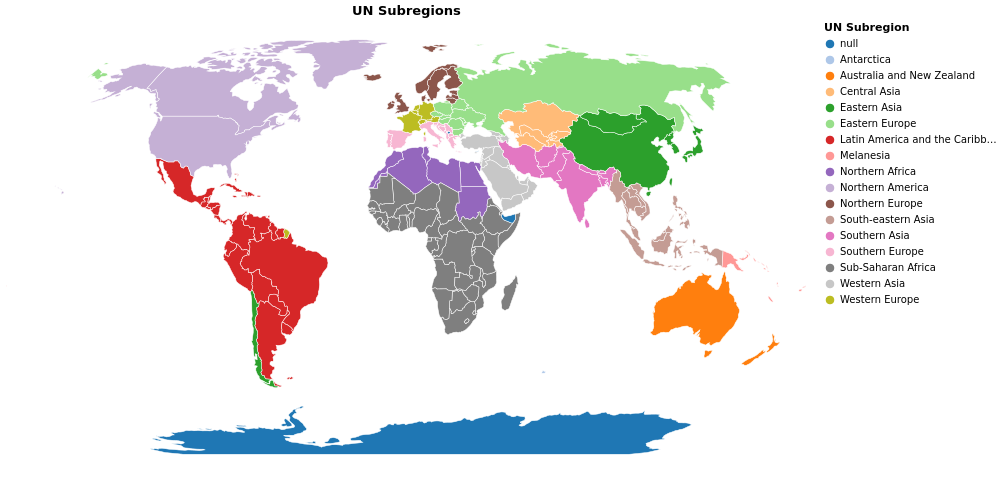

In [6]:
@vlplot(
    width=800, height=450,
    title="UN Subregions",
    projection={type=:naturalEarth1},
) +
@vlplot(
    mark={type=:geoshape, stroke=:white, strokeWidth=0.5},
    data={values=world, format={type=:topojson, feature=:countries}},
    transform=[{
        lookup=:id,
        from={
            data=geo,
            key=:ident_ccode,
            fields=["un_subregion_name", "un_subregion_code"]
        }
    }],
    color={
        field=:un_subregion_name,
        type=:nominal,
        title="UN Subregion",
        scale={scheme=:category20}
    },
    tooltip=[
        {field=:un_subregion_name, type=:nominal, title="Subregion"},
        {field=:un_subregion_code, type=:quantitative, title="Code"}
    ]
)

## 3. Continents

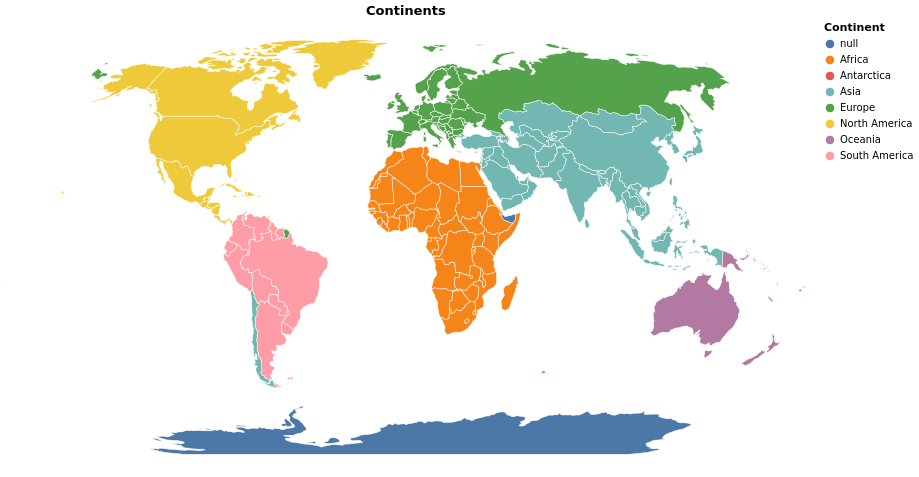

In [4]:
@vlplot(
    width=800, height=450,
    title="Continents",
    projection={type=:naturalEarth1},
) +
@vlplot(
    mark={type=:geoshape, stroke=:white, strokeWidth=0.5},
    data={values=world, format={type=:topojson, feature=:countries}},
    transform=[{
        lookup=:id,
        from={
            data=geo,
            key=:ident_ccode,
            fields=["continent", "continent_code"]
        }
    }],
    color={
        field=:continent,
        type=:nominal,
        title="Continent",
        scale={scheme=:tableau10}
    },
    tooltip=[
        {field=:continent, type=:nominal, title="Continent"},
        {field=:continent_code, type=:nominal, title="Code"}
    ]
)

## 4. Coverage gaps

Countries in the world map that have no UN region assignment (unmapped).

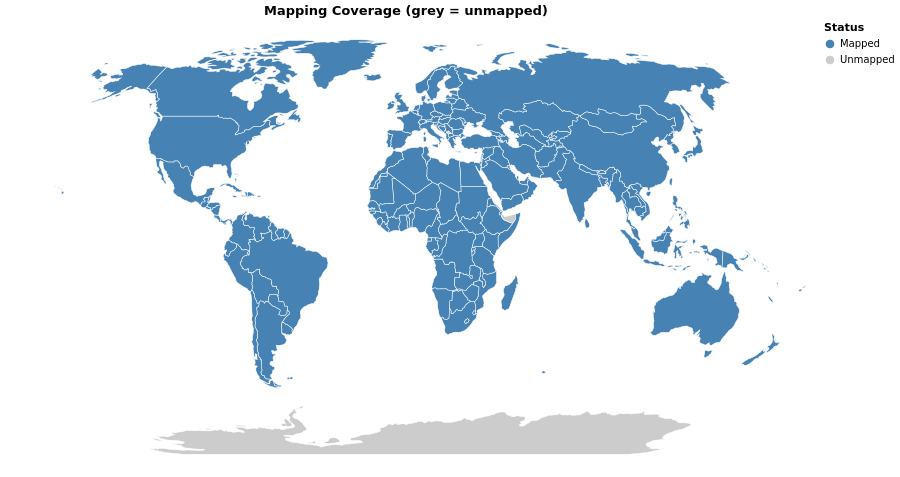

In [5]:
@vlplot(
    width=800, height=450,
    title="Mapping Coverage (grey = unmapped)",
    projection={type=:naturalEarth1},
) +
@vlplot(
    mark={type=:geoshape, stroke=:white, strokeWidth=0.5},
    data={values=world, format={type=:topojson, feature=:countries}},
    transform=[
        {
            lookup=:id,
            from={
                data=geo,
                key=:ident_ccode,
                fields=["un_region_name"]
            }
        },
        {calculate="datum.un_region_name == null ? 'Unmapped' : 'Mapped'", as=:status}
    ],
    color={
        field=:status,
        type=:nominal,
        title="Status",
        scale={domain=["Mapped", "Unmapped"], range=["steelblue", "#ccc"]}
    }
)

## Known Visual Quirks

The base map (VegaDatasets `world-110m` topojson) has rendering artifacts that do not reflect errors in our data:

| Visual Issue | Cause | Data Status |
|---|---|---|
| **French Guiana** shows as Western Europe | world-110m assigns French Guiana the polygon ID of France (250). It is a French overseas department, not a sovereign state, so it is not in QoG or our lookup as a separate entity. The UN classifies it under France. | Correct — not a data error |
| **Somaliland** (northern Somalia) appears unmapped | world-110m splits Somaliland as a separate polygon with a non-standard numeric code (~-99). Our lookup has Somalia (706) correctly mapped to Sub-Saharan Africa, but the Somaliland polygon doesn't join. | Cartographic artifact — Somalia data is complete |
| **Western Sahara** may appear unmapped | Disputed territory. In our lookup via `CARTOGRAPHIC_TERRITORIES` (ccode 732, ESH) but world-110m may use a different ID. | Known edge case |
| **Antarctica** appears mapped | Our lookup includes Antarctica (ccode 10, ATA) per the UN M49 standard. Only 1 entity. | Correct |

These quirks affect only map rendering. The pipeline's `apply_georegion_layer()` achieves 100% saturation on all 12,391 data rows — verified by the output integrity test suite.

### Previously fixed issues

| Issue | Fix |
|---|---|
| Chile (152) showed as Asia | Tibet had ccode 152 in the lookup instead of 9156. Corrected Tibet to use synthetic code, added Chile. |
| Yugoslavia (891) caused pipeline failure | Added to `GHOST_REGION_MAP` as Southern Europe (code 39). |
| VDR/SCG in lookup caused duplicate ccode joins | Removed historical entities (VDR, SCG, TIB) from geographic lookup — handled by pipeline mechanisms instead. |